# Setup

In [16]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import numpy as np

from torch import nn


from eharmony import grid
from eharmony import plotting
from eharmony.polar_harmonics import PolarHarmonics

In [3]:
K = 2
L = 3
ph = PolarHarmonics(K, L)
ph.Psi.shape

torch.Size([1, 14, 100, 360])

# Plotting the Polar Harmonics

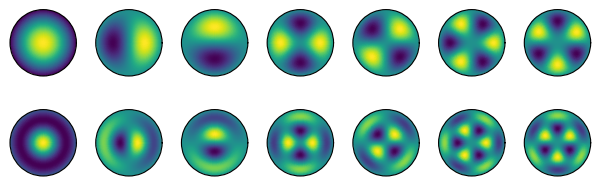

In [4]:
basis_fns = ph.Psi.view(K, L * 2 + 1, ph.num_radii, ph.num_phi)

fig = plt.figure(figsize=(2 * L, K))
subfigs = fig.subfigures(K, L * 2 + 1)
for k in range(K):
    for l in range(L * 2 + 1):
        ax = subfigs[k, l].add_subplot(projection="polar")
        plotting.plot_polar_fn(basis_fns[k, l].numpy(), ax=ax)

# Polar Harmonics Transform

In [6]:
r = torch.linspace(0, 1, 100)
phi = torch.linspace(0, 2 * np.pi, 360)
y = (1 - r).view(100, 1) @ (np.cos(phi) + np.sin(phi)).view(1, 360)

/tmp/ipykernel_866170/3123757906.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = (1 - r).view(100, 1) @ (np.cos(phi) + np.sin(phi)).view(1, 360)


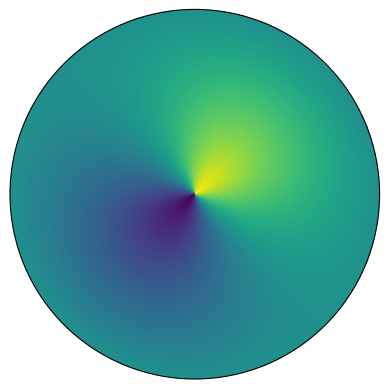

In [7]:
plotting.plot_polar_fn(y.numpy())

In [8]:
class PHT(nn.Module):
    def __init__(self, K=1, L=3, num_radii=100, num_phi=360):
        super().__init__()
        self.w_lin = nn.Linear(num_radii * num_phi, K * (L * 2 + 1))
        self.ph = PolarHarmonics(K, L)

    def forward(self, x, coords=None):
        w = self.w_lin(x)
        return self.ph(w, coords), w.detach()

In [9]:
K = 5
L = 3
ph_model = PHT(K, L)
optimizer = torch.optim.Adam(ph_model.parameters(), lr=1e-4)

for iter in range(200):
    y_pred, _ = ph_model(y.view(1, -1))
    loss = (y_pred - y).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        print(f"iteration: {iter} loss: {loss.item()}")

iteration: 0 loss: 0.8422505855560303
iteration: 10 loss: 8.650805473327637
iteration: 20 loss: 2.9981982707977295
iteration: 30 loss: 0.5508551001548767
iteration: 40 loss: 0.11873971670866013
iteration: 50 loss: 0.061447516083717346
iteration: 60 loss: 0.05717281624674797
iteration: 70 loss: 0.05181809887290001
iteration: 80 loss: 0.04393871873617172
iteration: 90 loss: 0.03709475323557854
iteration: 100 loss: 0.03748499974608421
iteration: 110 loss: 0.03677533194422722
iteration: 120 loss: 0.036760978400707245
iteration: 130 loss: 0.03665385767817497
iteration: 140 loss: 0.03665753826498985
iteration: 150 loss: 0.036650534719228745
iteration: 160 loss: 0.036646485328674316
iteration: 170 loss: 0.03664598613977432
iteration: 180 loss: 0.036645930260419846
iteration: 190 loss: 0.03664588928222656


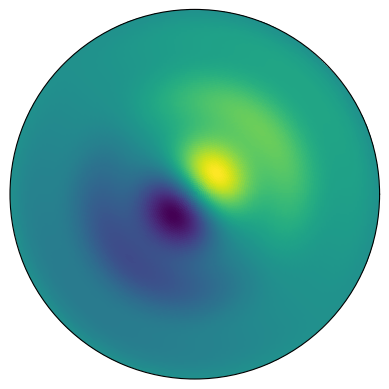

In [10]:
with torch.no_grad():
    pred, w = ph_model(y.view(1, -1))
    plotting.plot_polar_fn(pred.squeeze().numpy())

In [11]:
w_ph = torch.einsum("bwrp,bw->bwrp", ph_model.ph.Psi, w).view(K, 2 * L + 1, ph_model.ph.num_radii, ph_model.ph.num_phi)
w.numpy().round(1).reshape(K, -1)

array([[ 0. ,  0.7,  0.7, -0. , -0. , -0. , -0. ],
       [ 0. ,  0.2,  0.2, -0. , -0. , -0. , -0. ],
       [ 0. ,  0.1,  0.1, -0. , -0. , -0. , -0. ],
       [-0. ,  0.1,  0.1, -0. , -0. , -0. , -0. ],
       [-0. ,  0.1,  0.1, -0. , -0. , -0. , -0. ]], dtype=float32)

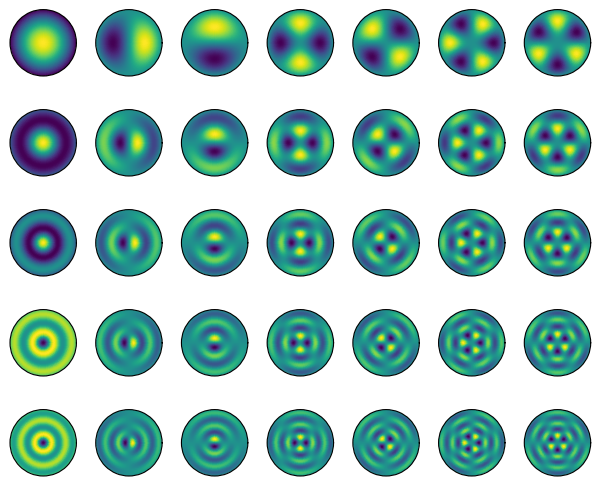

In [12]:
fig = plt.figure(figsize=(2 * L, K))
subfigs = fig.subfigures(K, L * 2 + 1)
for k in range(K):
    for l in range(L * 2 + 1):
        ax = subfigs[k, l].add_subplot(projection="polar")
        plotting.plot_polar_fn(w_ph[k, l].numpy(), ax=ax)

In [13]:
ph_model(y.view(1, -1), torch.tensor([[0.1, np.pi / 4]]))[0]

tensor([[[1.1952]]], grad_fn=<SumBackward1>)

In [17]:
r2d, p2d = grid.polar_grid(1.0, 10, 90)

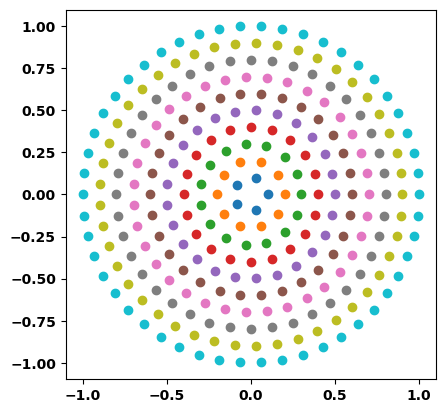

In [18]:
def circle_points(r, n):
    circles = []
    for r, n in zip(r, n):
        t = np.linspace(0, 2*np.pi, n, endpoint=False)
        x = r * np.cos(t)
        y = r * np.sin(t)
        circles.append(np.c_[x, y])
    return circles

n = [5*(i+1) for i in range(10)]
r = np.linspace(0.1, 1, 10)
circles = circle_points(r, n)

fig, ax = plt.subplots()
for circle in circles:
    ax.scatter(circle[:, 0], circle[:, 1])
ax.set_aspect('equal')
plt.show()